In [1]:
%load_ext autoreload
%autoreload 2
import xarray as xr
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib as mpl
from get_ddf import get_hourly_df
from data_handling import *
import statsmodels.api as sm
from scipy.stats import gaussian_kde as kde
import sys 
import joblib
from scipy.optimize import minimize
sys.path.append('/trace/home/cvwilson/research/PEBSI/shop/plotting/')
from plotting_fxns import *

import socket
if 'trace' in socket.gethostname():
    base_fp = '/trace/group/rounce/cvwilson/Output/ddf/'
    home_fp = '/trace/home/cvwilson/research/'
else:
    base_fp = 'C:/Users/cvw30/Research/Output/'
    home_fp = 'C:/Users/cvw30/Research/'

colors = ['#63c4c7','#fcc02e','#4D559C','#60C252','#BF1F6A',
              '#F77808','#298282','#999999','#FF89B0','#427801']
coord_dict = {'wolverine':'60.5_-148.7',
                'kahiltna':'63.0_-151.2',
                'kennicott':'61.5_-143.1',
                'taku':'58.5_-134.3',
                'lemon_creek':'58.5_-134.3',
                'gulkana':'63.5_-145.6'}
site_dict = {
    'kahiltna':['K17b','K53'], # KAHILTNA     'KPS','K14k',
    'kennicott':['GTH','KC31','GTL'], # KENNICOTT
    'gulkana':['AU','B','D'], # GULKANA
    'wolverine':['N','B','EC'], # WOLVERINE
    'lemon_creek':['B','C','D'], # LEMON CREEK
    'taku':['MG1','NWB1','TKG3'], # TAKU
}

/trace/home/cvwilson/research/PEBSI/shop/plotting/plotting_fxns.py:201: SyntaxWarning: invalid escape sequence '\c'
  axis.set_ylabel('Temperature ($^{\circ}$C)')
/trace/home/cvwilson/research/PEBSI/shop/plotting/plotting_fxns.py:1233: SyntaxWarning: invalid escape sequence '\c'
  units = {'layerBC':'ppb','layerdust':'ppm','layerOC':'ppb','layertemp':'$^{\circ}$C',


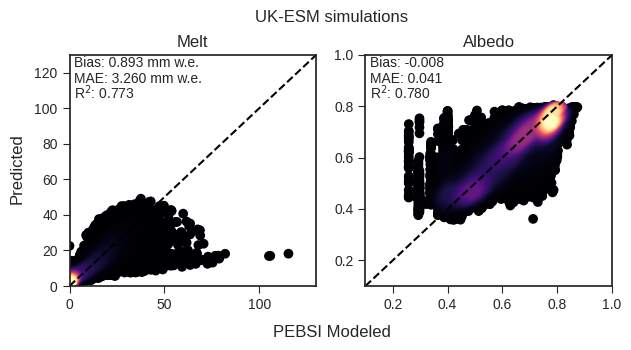

In [7]:
albedo_regression_vars = ['PDD_cumsum','log_bc_5d_rolling','days_since_acc','SWin']
model = joblib.load(base_fp + 'albedo_model.joblib')

df = pd.read_csv(base_fp + 'UKESM_all_snow_daily_df.csv')
f_SW = 1.312e-6
f_T = 1.668

# get "baseline" prediction of melt
# df['SW_absorbed'] = df['SWin'] * (1 - df['albedo'])
# df['melt_base'] = df['SW_absorbed'] * f_SW + df['positive_temp'] * f_T

# get ML albedo and shortwave absorbed
df['log_bc_5d_rolling'] = np.log1p(df['bc_5d_rolling'] * 1e9)
df['albedo_ML'] = model.predict(df[albedo_regression_vars])
df['SW_absorbed_ML'] = df['SWin'] * (1 - df['albedo_ML'])

# calcualte melt from ML shortwave term
df['melt_ML'] = df['SW_absorbed_ML'] * f_SW + df['positive_temp'] * f_T

# plot
fig, axes = plt.subplots(1, 2, figsize=(7, 3))
axes = axes.flatten()
for ax, var in zip(axes, ['melt','albedo']):
    # get x and y
    x = df[var].values 
    y = df[var + '_ML'].values

    # KDE analysis
    xy = np.vstack([x, y])
    z = kde(xy)(xy)
    idx = z.argsort()
    x, y, z = x[idx], y[idx], z[idx]

    # get error metrics
    bias = np.nanmean(y - x)
    mae = np.nanmean(np.abs(y - x))
    r2 = 1 - np.sum(np.square(y - x)) / np.sum(np.square(x - np.mean(x)))

    # get min/max
    data_min = 0.1 if var == 'albedo' else 0 # np.min([x, y]) * 0.95
    data_max = 1 if var == 'albedo' else 130 # np.max([x, y]) * 1.05
    ax.set_xlim(data_min, data_max)
    ax.set_ylim(data_min, data_max)

    # plot
    ax.scatter(x, y, c=z, cmap='magma', label='Predictions')
    ax.plot([data_min, data_max],[data_min, data_max],'k--', label='1:1')

    unit = '' if var == 'albedo' else ' mm w.e.'
    ax.text(0.02, 0.95, f'Bias: {bias:.3f}'+unit, transform=ax.transAxes)
    ax.text(0.02, 0.88, f'MAE: {mae:.3f}'+unit, transform=ax.transAxes)
    ax.text(0.02, 0.81, f'R$^2$: {r2:.3f}', transform=ax.transAxes)
    ax.set_title(var.capitalize())
    ax.tick_params(length=5)

fig.suptitle('UK-ESM simulations', y=1.03)
fig.supxlabel('PEBSI Modeled', y=-0.07)
fig.supylabel('Predicted', x=0.04)
plt.savefig('/trace/group/rounce/cvwilson/figs/ddf/ukesm_regression_results.png', dpi=300, bbox_inches='tight')
# plt.show()

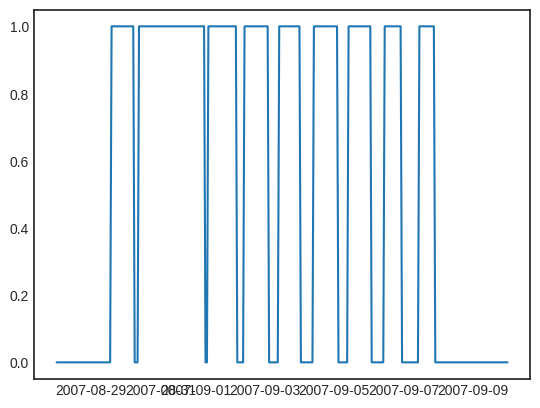

In [2]:
ds = xr.open_dataset(base_fp + 'gulkanaD_2026_04_17_ukesm_0.nc')
dates = pd.date_range('2007-08-28','2007-09-10')

# fig, axes = visualize_layers(ds, dates, ['layergrainsize'])
# axes[0].axvline(pd.to_datetime('2007-08-30'))
# axes[0].axvline(pd.to_datetime('2007-09-08'))
# plt.show()
ds = ds.sel(time=slice(dates[0], dates[-1]))
plt.plot(ds.time, ds.layertype.isel(layer=0))

In [17]:
df.loc[df['glaciersite'] == 'gulkanaD'].loc[df['albedo'] < 0.3]

,time,melt,positive_temp,accum,rain,albedo,bc_dep,SWin,LWin,days_since_acc,bc_dep_cumsum,PDD_cumsum,bc_5d_rolling,glacier,glaciersite,log_bc_5d_rolling,albedo_ML,SW_absorbed_ML,melt_ML
57014,2004-07-26,23.374256,3.770500,0.047293,5.000182,0.258234,5.357652e-08,1.038388e+07,25376850.0,0.0,0.000024,493.667779,4.369303e-07,gulkana,gulkanaD,6.082060,0.587891,4.279293e+06,11.903627
57015,2004-07-27,27.987616,4.774667,0.000000,20.034565,0.258234,4.590396e-08,1.313725e+07,26907942.0,1.0,0.000024,498.442446,4.358914e-07,gulkana,gulkanaD,6.079685,0.472872,6.925006e+06,17.049752
57525,2006-08-16,17.439811,3.462167,1.041218,14.847273,0.258234,3.606280e-08,1.224059e+07,26317924.0,0.0,0.000011,373.638087,1.738903e-07,gulkana,gulkanaD,5.164159,0.561155,5.371729e+06,12.822602
57526,2006-08-17,15.505704,2.724667,2.592446,24.461916,0.258234,5.374716e-08,7.594660e+06,27032028.0,0.0,0.000011,376.362754,1.889975e-07,gulkana,gulkanaD,5.247011,0.619319,2.891144e+06,8.337925
57527,2006-08-18,11.247739,2.318807,9.553560,64.599054,0.258234,9.295378e-08,4.061038e+06,27196942.0,0.0,0.000011,378.681561,2.602236e-07,gulkana,gulkanaD,5.565377,0.629716,1.503738e+06,5.840674
57784,2007-08-30,17.612057,5.333000,0.184379,2.565740,0.258234,2.639825e-08,1.226841e+07,24018224.0,0.0,0.000011,564.080930,7.295512e-08,gulkana,gulkanaD,4.303458,0.626242,4.585422e+06,14.911518
57785,2007-08-31,14.909400,4.258000,0.000000,12.924836,0.258234,5.623881e-08,8.830765e+06,25668734.0,1.0,0.000011,568.338930,1.187968e-07,gulkana,gulkanaD,4.785797,0.500141,4.414140e+06,12.893696
57786,2007-09-01,18.525722,3.958000,0.143476,2.479050,0.258234,5.176084e-08,1.275285e+07,23508414.0,0.0,0.000011,572.296930,1.650247e-07,gulkana,gulkanaD,5.112137,0.566756,5.525103e+06,13.850879
57787,2007-09-02,17.191788,3.720500,0.350946,3.978001,0.258234,2.957073e-08,1.156582e+07,23634598.0,0.0,0.000011,576.017430,1.789979e-07,gulkana,gulkanaD,5.192945,0.559198,5.098235e+06,12.894678
57788,2007-09-03,17.577818,2.953833,0.935011,3.629200,0.258234,4.121379e-08,1.102644e+07,24366672.0,0.0,0.000011,578.971263,2.051824e-07,gulkana,gulkanaD,5.328761,0.564022,4.807290e+06,11.234159


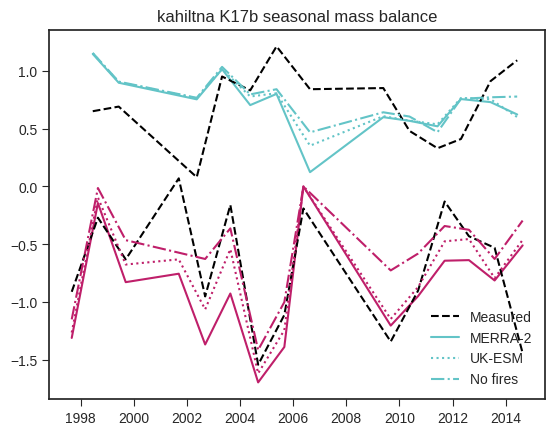

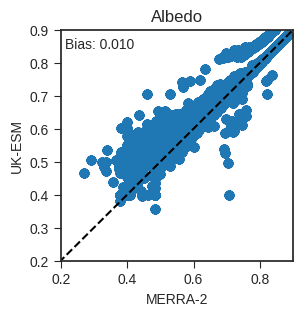

In [ ]:
glacier, site = 'kahiltna', 'K17b'

ds_merra2 = xr.open_dataset(base_fp + glacier+site+'_2026_04_06_merra2_0.nc')
ds_ukesm = xr.open_dataset(base_fp + glacier+site+'_2026_04_06_gfed_0.nc')
ds_nofires = xr.open_dataset(base_fp + glacier+site+'_2026_04_06_nofires_0.nc')

mb = MassBalance(glacier, site)
mb.get_model_mb(ds_merra2)
mod_merra2, meas = (mb.mod, mb.meas)
fig, ax = mb.plot_mb(mod_label='MERRA-2')

mb.get_model_mb(ds_ukesm)
mod_ukesm, meas = (mb.mod, mb.meas)
ends = mb.period_ends
if 'seasonal' in mb.dataset:
    idx_summer = mb.idx_summer 
    idx_winter = mb.idx_winter
    ax.plot(ends[idx_summer], mod_ukesm[idx_summer], color=colors[4], linestyle=':')
    ax.plot(ends[idx_winter], mod_ukesm[idx_winter], color=colors[0], linestyle=':', label='UK-ESM')
else:
    ax.plot(ends, mod_ukesm, color=colors[0], linestyle=':', label='UK-ESM')

mb.get_model_mb(ds_nofires)
mod_nofires, meas = (mb.mod, mb.meas)
if 'seasonal' in mb.dataset:
    idx_summer = mb.idx_summer 
    idx_winter = mb.idx_winter
    ax.plot(ends[idx_summer], mod_nofires[idx_summer], color=colors[4], linestyle='-.')
    ax.plot(ends[idx_winter], mod_nofires[idx_winter], color=colors[0], linestyle='-.', label='No fires')
else:
    ax.plot(ends, mod_nofires, color=colors[0], linestyle='-.', label='No fires')

ax.legend()
ax.tick_params(length=5)
plt.show()

albedo_merra2 = ds_merra2.albedo.values # .layerBC.isel(layer=0).values # 
albedo_ukesm = ds_ukesm.albedo.values
fig, ax = plt.subplots(figsize=(3, 3))
ax.scatter(albedo_merra2, albedo_ukesm)
bias = np.nanmean(albedo_ukesm - albedo_merra2)
ax.text(0.02, 0.92, f'Bias: {bias:.3f}', transform=ax.transAxes)
ax.plot([0,1],[0,1],'k--',label='1:1')
ax.set_xlim(0.2,0.9)
ax.set_ylim(0.2,0.9)
ax.set_ylabel('UK-ESM')
ax.set_xlabel('MERRA-2')
ax.set_title('Albedo')
ax.tick_params(length=5)
plt.show()

In [ ]:
site_dict = {
    'kahiltna':['K17b','K53','K14k'], # KAHILTNA     'KPS',
    'kennicott':['KC31','GTL','GTH',], # KENNICOTT 
    'gulkana':['AU','B','D'], # GULKANA  
    'wolverine':['N','B','EC'], # WOLVERINE
    'lemon_creek':['B','C', 'D'], # LEMON CREEK
    'taku':['NWB1','MG1','TKG3'], # TAKU    
}

all_albedo = {'mod':[], 'meas':[], 'time':[]}
for glacier in ['gulkana']: # site_dict:
    for site in site_dict[glacier]:
        albedo = Albedo(glacier, site, use='all')
        ds = xr.open_dataset(base_fp + glacier + site +'_2026_03_19_long_0.nc')
        albedo.get_model_albedo(ds, months_range=list(range(4, 9)))
        # albedo.plot_timeseries()

        for mod, meas, date in zip(albedo.mod, albedo.meas, albedo.time):
            all_albedo['mod'].append(mod)
            all_albedo['meas'].append(meas)
            all_albedo['time'].append(date)

In [ ]:
fig, ax = plt.subplots(figsize=(4, 4))
cmap = plt.get_cmap('viridis')
norm = mpl.colors.Normalize(vmin=4, vmax=8)
markers = {'wolverine':'*', 'gulkana':'o', 'kahiltna':'3', 'kennicott':'^','lemon_creek':'.','taku':'1'}
# for glacier in site_dict:
#     for site in site_dict[glacier]:
#         albedo = Albedo(glacier, site)
#         ds = xr.open_dataset(base_fp + glacier + site +'_2026_03_04_base_3.nc')
#         albedo.get_model_albedo(ds)
#         ax.scatter(albedo.meas, albedo.mod, alpha=0.6, label=glacier, c=cmap(norm(pd.to_datetime(albedo.time).month)), marker=markers[glacier])
ax.scatter(all_albedo['meas'], all_albedo['mod'], alpha=0.6, label='Data', c=cmap(norm(pd.to_datetime(all_albedo['time']).month)))
ax.plot([0,1],[0,1],'k--',label='1:1')

bias = np.nanmean(np.array(all_albedo['mod']) - np.array(all_albedo['meas']))
mae = np.nanmean(np.abs(np.array(all_albedo['meas']) - np.array(all_albedo['mod'])))
ax.text(0.02, 0.95, f'Bias: {bias:.3f}', transform=ax.transAxes)
ax.text(0.02, 0.88, f'MAE: {mae:.3f}', transform=ax.transAxes)

ax.legend(frameon=True)
ax.set_xlim(0, 1)
ax.set_ylim(0, 1)
ax.tick_params(length=5)
ax.set_ylabel('Modeled albedo')
ax.set_xlabel('Measured albedo')
plt.show()

In [14]:
measurements = {'B':('2024-06-19', 5.102, 65.19),
                'D':('2024-08-21', 10.51, 262.45)}

for site in measurements:
    ds = xr.open_dataset(base_fp + f'gulkana{site}_2026_03_19_long_0.nc')
    
    # dsc = ds.sel(time=slice(pd.to_datetime(measurements[site][0]) - pd.Timedelta(days=1), pd.to_datetime(measurements[site][0]) + pd.Timedelta(days=1)))
    # plt.plot(dsc.time, dsc.layerBC.isel(layer=range(3)).mean(dim='layer'))
    # plt.show()
    date = measurements[site][0]
    modeled_bc = ds.sel(time=pd.to_datetime(date)).layerBC.isel(layer=range(1)).mean()
    modeled_dust = ds.sel(time=pd.to_datetime(date)).layerdust.isel(layer=range(1)).mean()
    print(f'Gulkana {site} on {date}')
    print('   Measured BC:', measurements[site][1],'ppb')
    print(f'   Modeled BC: {modeled_bc:.2f} ppb')
    print('   Measured dust:', measurements[site][2],'ppm')
    print(f'   Modeled dust: {modeled_dust:.2f} ppm')

Gulkana B on 2024-06-19
   Measured BC: 5.102 ppb
   Modeled BC: 101.40 ppb
   Measured dust: 65.19 ppm
   Modeled dust: 1.70 ppm
Gulkana D on 2024-08-21
   Measured BC: 10.51 ppb
   Modeled BC: 19.55 ppb
   Measured dust: 262.45 ppm
   Modeled dust: 0.17 ppm
